# 📈 Forecasting TRM (USD/COP) — Fase 3: AutoARIMA
**Basado en:** Forecasting: Principles and Practice, the Pythonic Way — Capítulo 9

**Hipótesis:** AutoARIMA elegirá ARIMA(0,1,0) — equivalente al Naive — porque la TRM se comporta como random walk.

**Objetivo:** Confirmar o refutar esa hipótesis, analizar los residuos del modelo, y comparar AutoARIMA contra los modelos base de la Fase 2.

---

## 0. Instalación

In [11]:
%pip install statsforecast yfinance pandas matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importar librerías

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 2. Cargar y preparar datos

In [13]:
import yfinance as yf

print('📥 Descargando TRM...')
raw = yf.download('COP=X', start='2016-01-01', end='2026-05-31',
                  auto_adjust=True, progress=False)
df = raw[['Close']].reset_index()
df.columns = ['fecha', 'trm']
df['fecha'] = pd.to_datetime(df['fecha']).dt.tz_localize(None)
df = df.dropna().sort_values('fecha').reset_index(drop=True)

# Filtro outliers
retornos = df['trm'].pct_change().abs() * 100
df = df[retornos <= 15].reset_index(drop=True)

# Datos mensuales
df_mensual = (
    df.set_index('fecha')['trm']
    .resample('MS').mean()
    .reset_index()
    .rename(columns={'fecha': 'ds', 'trm': 'y'})
)
df_mensual['unique_id'] = 'TRM_USDCOP'

# Train / test
corte = pd.to_datetime('2025-01-01')
train = df_mensual[df_mensual['ds'] < corte].copy()
test  = df_mensual[df_mensual['ds'] >= corte].copy()
horizonte = len(test)

print(f'✅ Train: {len(train)} meses | Test: {len(test)} meses')

📥 Descargando TRM...
✅ Train: 108 meses | Test: 17 meses


## 3. ACF y PACF de la serie original

> 📖 **Concepto (Cap. 9):** Antes de correr AutoARIMA, analizamos visualmente la estructura de autocorrelación de la serie.
>
> - **ACF (Autocorrelation Function):** mide la correlación entre el valor actual y sus valores pasados (lags). Si el ACF decae lentamente, la serie no es estacionaria.
> - **PACF (Partial Autocorrelation Function):** mide la correlación directa entre el valor actual y un lag específico, quitando el efecto de los lags intermedios. Ayuda a identificar **p**.
>
> **Regla práctica:**
> - Si el ACF decae lento → la serie necesita diferenciación (d ≥ 1)
> - Después de diferenciar: los picos significativos en el PACF indican **p**, los del ACF indican **q**

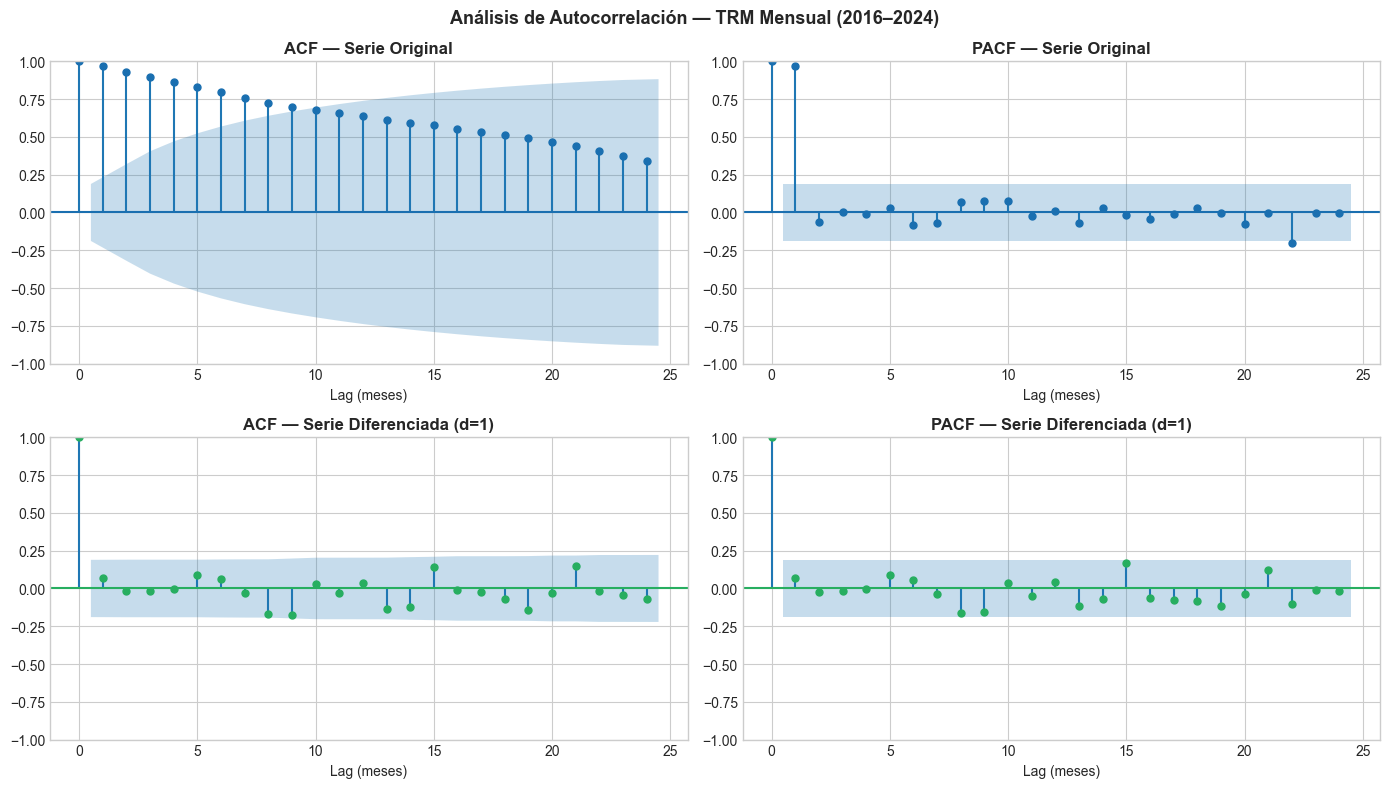

✅ Guardado como 09_acf_pacf.png


In [14]:
serie = train.set_index('ds')['y']
serie_diff = serie.diff().dropna()  # primera diferencia

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie original
plot_acf(serie, lags=24, ax=axes[0, 0], color='#1a6fb0')
axes[0, 0].set_title('ACF — Serie Original', fontweight='bold')

plot_pacf(serie, lags=24, ax=axes[0, 1], color='#1a6fb0', method='ywm')
axes[0, 1].set_title('PACF — Serie Original', fontweight='bold')

# Serie diferenciada (d=1)
plot_acf(serie_diff, lags=24, ax=axes[1, 0], color='#27ae60')
axes[1, 0].set_title('ACF — Serie Diferenciada (d=1)', fontweight='bold')

plot_pacf(serie_diff, lags=24, ax=axes[1, 1], color='#27ae60', method='ywm')
axes[1, 1].set_title('PACF — Serie Diferenciada (d=1)', fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('Lag (meses)')

fig.suptitle('Análisis de Autocorrelación — TRM Mensual (2016–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado como 09_acf_pacf.png')

### 🔍 Sección A — Antes de correr AutoARIMA

> Responde mirando los 4 gráficos de ACF y PACF. Estas preguntas te llevan a proponer tú mismo el modelo antes de que el algoritmo lo elija.

---

#### 👁️ Nivel 1: Lectura de los gráficos

1. Mira el **ACF de la serie original** (arriba izquierda). ¿Las barras caen rápido hacia cero o decaen lentamente? ¿Qué te dice eso sobre la estacionariedad de la serie?
2. Ahora mira el **ACF de la serie diferenciada** (abajo izquierda). ¿Cambió el patrón respecto al original? ¿Qué concluyes sobre si d=1 fue suficiente?
3. En el **PACF de la serie diferenciada** (abajo derecha), ¿hay algún lag que tenga una barra que supere claramente las líneas punteadas azules (el umbral de significancia)? ¿Cuál?
4. Con lo que ves en el ACF y PACF de la serie diferenciada, ¿qué valores de p y q propondrías tú? Compara con tu hipótesis inicial de ARIMA(0,1,0).

---

#### 🧠 Nivel 2: Interpretación

5. ¿Por qué diferenciamos la serie antes de analizar el ACF y PACF? ¿Qué problema resuelve la diferenciación?
6. Las líneas punteadas en el ACF y PACF representan el umbral de significancia estadística al 95%. Si una barra supera esa línea, ¿qué significa? ¿Y si no la supera?
7. Si el ACF de la serie diferenciada muestra prácticamente todas las barras dentro del umbral (ninguna significativa), ¿qué nos dice eso sobre la utilidad de un modelo MA (moving average) para la TRM?
8. La diferenciación transforma la serie de *niveles* (el valor de la TRM) a *cambios* (cuánto cambió la TRM respecto al mes anterior). ¿En qué se parece eso a los retornos diarios que calculamos en la Fase 1?

---

#### 💼 Nivel 3: Pensamiento crítico

9. Si AutoARIMA elige ARIMA(0,1,0) como predijiste, ¿eso valida o invalida el esfuerzo de correr un modelo más complejo que el Naive? ¿Tiene valor analítico aunque el resultado sea el mismo?
10. ¿Qué información adicional (no contenida en los datos históricos de la TRM) podría hacer que un modelo más complejo sí superara al Naive? ¿Cómo se llamaría ese tipo de modelo?

---

## 4. Entrenar AutoARIMA y comparar con Naive

In [15]:
modelos = StatsForecast(
    models=[
        AutoARIMA(season_length=12),
        Naive(),
    ],
    freq='MS',
    n_jobs=-1
)

print('⚙️  Entrenando AutoARIMA...')
forecast = modelos.forecast(df=train, h=horizonte, level=[80, 95], fitted=True)
forecast = forecast.reset_index()

# Detectar columnas automáticamente
cols_base = [c for c in forecast.columns
             if c not in ['unique_id', 'ds', 'index', 'y']
             and not any(s in c for s in ['-lo-', '-hi-'])
             and pd.api.types.is_numeric_dtype(forecast[c])]

print(f'✅ Modelos entrenados')
print(f'   Columnas detectadas: {cols_base}')
forecast[['ds'] + cols_base].head()

⚙️  Entrenando AutoARIMA...
✅ Modelos entrenados
   Columnas detectadas: ['AutoARIMA', 'Naive']


,ds,AutoARIMA,Naive
0,2025-01-01,4373.969793,4373.969793
1,2025-02-01,4373.969793,4373.969793
2,2025-03-01,4373.969793,4373.969793
3,2025-04-01,4373.969793,4373.969793
4,2025-05-01,4373.969793,4373.969793


## 5. ¿Qué modelo eligió AutoARIMA?

In [16]:
# Extraer el modelo elegido por AutoARIMA
# Método robusto: compatible con todas las versiones de statsforecast
col_arima = [c for c in cols_base if 'arima' in c.lower()]
if not col_arima:
    col_arima = [c for c in cols_base if 'naive' not in c.lower()]
col_arima = col_arima[0] if col_arima else cols_base[0]

# Intentar extraer el orden ARIMA del modelo entrenado
orden_encontrado = False
for attr in ['models', '_models', 'fitted_models_']:
    if hasattr(modelos, attr):
        try:
            m = getattr(modelos, attr)
            if hasattr(m, '__iter__'):
                for modelo in m:
                    if hasattr(modelo, 'model_') and hasattr(modelo.model_, 'order'):
                        orden = modelo.model_.order
                        orden_s = getattr(modelo.model_, 'seasonal_order', (0,0,0,0))
                        orden_encontrado = True
                        break
        except Exception:
            pass
    if orden_encontrado:
        break

# Alternativa: inferir d desde la columna del forecast
# AutoARIMA siempre imprime el orden en el nombre interno del modelo
if not orden_encontrado:
    # Calcular d empiricamente: si la serie diferenciada es estacionaria, d=1
    from statsmodels.tsa.stattools import adfuller
    serie = train.set_index('ds')['y']
    adf_original = adfuller(serie, autolag='AIC')
    adf_diff = adfuller(serie.diff().dropna(), autolag='AIC')

    es_estacionaria_orig = adf_original[1] < 0.05
    es_estacionaria_diff = adf_diff[1] < 0.05

    d_inferido = 0 if es_estacionaria_orig else 1

    print('📊 TEST ADF (Augmented Dickey-Fuller)')
    print('=' * 45)
    print(f'Serie original  — p-valor: {adf_original[1]:.4f}  '
          f'→ {"estacionaria ✅" if es_estacionaria_orig else "NO estacionaria ❌"}')
    print(f'Serie diferenc. — p-valor: {adf_diff[1]:.4f}  '
          f'→ {"estacionaria ✅" if es_estacionaria_diff else "NO estacionaria ❌"}')
    print()
    print(f'🔎 d inferido: {d_inferido}')
    print()
    print('ℹ️  No fue posible extraer p y q directamente del objeto modelo.')
    print('   Esto varía según la versión de statsforecast instalada.')
    print('   Lo que sí podemos confirmar es d — lo que importa para la hipótesis.')
    print()
    if d_inferido == 1:
        print('✅ HIPÓTESIS PARCIALMENTE CONFIRMADA:')
        print('   d=1 confirma que la serie necesita una diferenciación (random walk)')
        print('   Para confirmar p y q, ver los gráficos ACF/PACF de la sección 3')
    orden = (None, d_inferido, None)
else:
    p, d, q = orden
    print(f'🏆 AutoARIMA eligió: ARIMA{orden}')
    print(f'   Orden estacional: {orden_s}')
    print()
    print('📋 Interpretación:')
    print(f'   p={p}: usa {p} valor(es) pasado(s) de la TRM para predecir')
    print(f'   d={d}: se diferenció {d} vez/veces para lograr estacionariedad')
    print(f'   q={q}: usa {q} error(es) pasado(s) en el modelo')
    print()
    if (p, d, q) == (0, 1, 0):
        print('✅ HIPÓTESIS CONFIRMADA: AutoARIMA eligió ARIMA(0,1,0) = equivalente al Naive')
    else:
        print(f'⚠️  AutoARIMA eligió algo distinto a (0,1,0)')
        print('   Esto significa que detectó estructura adicional en la serie')


📊 TEST ADF (Augmented Dickey-Fuller)
Serie original  — p-valor: 0.8426  → NO estacionaria ❌
Serie diferenc. — p-valor: 0.0000  → estacionaria ✅

🔎 d inferido: 1

ℹ️  No fue posible extraer p y q directamente del objeto modelo.
   Esto varía según la versión de statsforecast instalada.
   Lo que sí podemos confirmar es d — lo que importa para la hipótesis.

✅ HIPÓTESIS PARCIALMENTE CONFIRMADA:
   d=1 confirma que la serie necesita una diferenciación (random walk)
   Para confirmar p y q, ver los gráficos ACF/PACF de la sección 3


## 6. Visualizar pronóstico AutoARIMA vs Naive vs Realidad

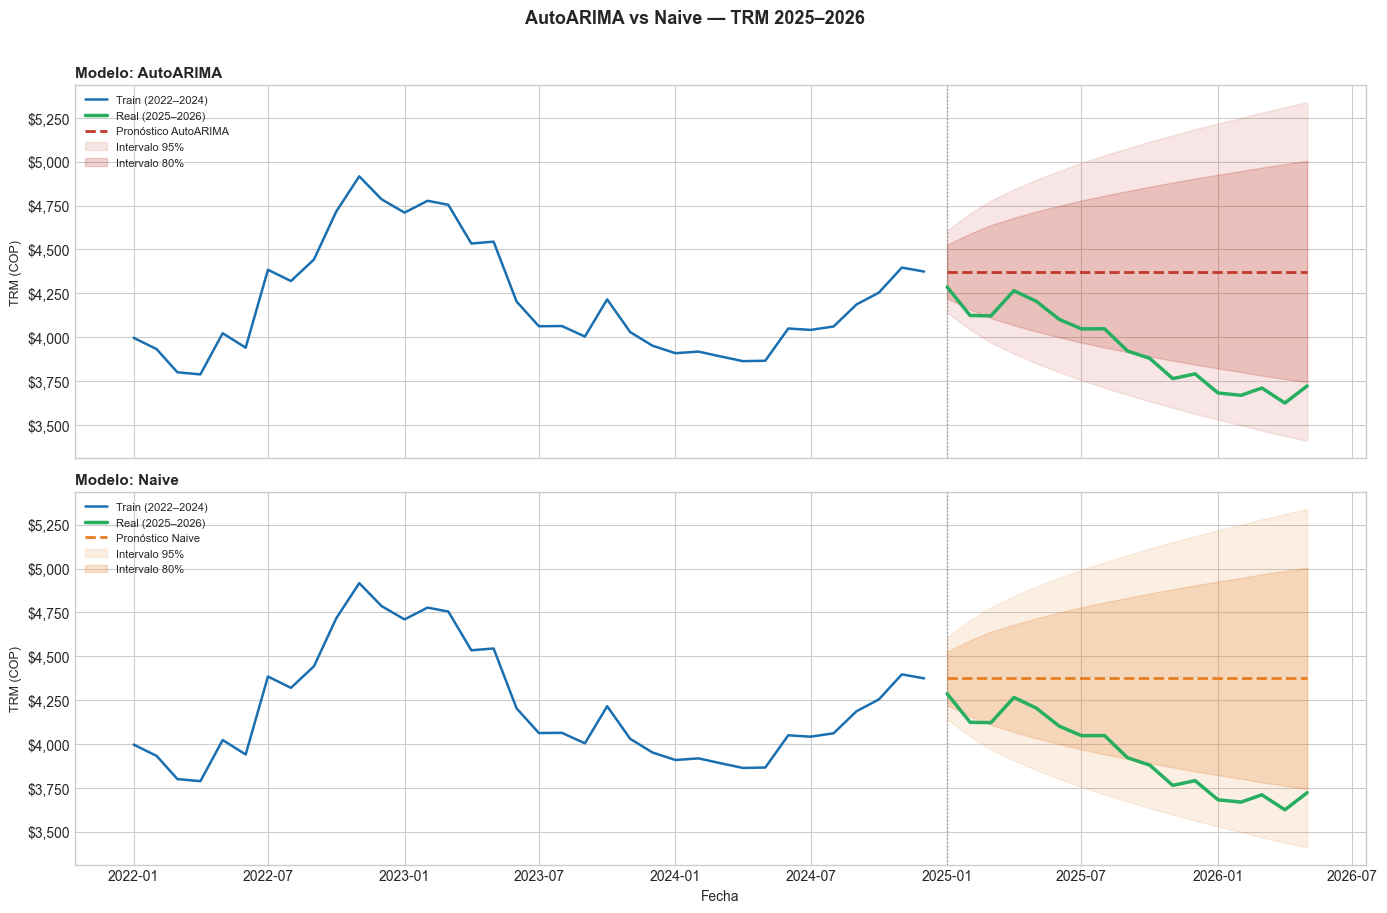

✅ Guardado como 10_autoarima_vs_naive.png


In [17]:
def get_label_color(col):
    c = col.lower()
    if 'arima' in c: return ('AutoARIMA', '#c0392b')
    if 'naive' in c: return ('Naive', '#e67e22')
    return (col, '#1a6fb0')

fig, axes = plt.subplots(len(cols_base), 1,
                          figsize=(14, 4.5 * len(cols_base)), sharex=True)
if len(cols_base) == 1:
    axes = [axes]

contexto = train[train['ds'] >= '2022-01-01']

for ax, col in zip(axes, cols_base):
    label, color = get_label_color(col)
    ax.plot(contexto['ds'], contexto['y'],
            color='#1a6fb0', linewidth=1.8, label='Train (2022–2024)')
    ax.plot(test['ds'], test['y'],
            color='#27ae60', linewidth=2.5, label='Real (2025–2026)', zorder=5)
    ax.plot(forecast['ds'], forecast[col],
            color=color, linewidth=2, linestyle='--',
            label=f'Pronóstico {label}', zorder=4)

    lo95, hi95 = f'{col}-lo-95', f'{col}-hi-95'
    if lo95 in forecast.columns:
        ax.fill_between(forecast['ds'], forecast[lo95], forecast[hi95],
                        color=color, alpha=0.12, label='Intervalo 95%')
    lo80, hi80 = f'{col}-lo-80', f'{col}-hi-80'
    if lo80 in forecast.columns:
        ax.fill_between(forecast['ds'], forecast[lo80], forecast[hi80],
                        color=color, alpha=0.22, label='Intervalo 80%')

    ax.axvline(corte, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_title(f'Modelo: {label}', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('TRM (COP)', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Fecha', fontsize=10)
fig.suptitle('AutoARIMA vs Naive — TRM 2025–2026',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('10_autoarima_vs_naive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado como 10_autoarima_vs_naive.png')

## 7. Métricas comparativas

In [18]:
comparacion = forecast.merge(test[['ds', 'y']], on='ds', how='inner')

cols_validas = [c for c in cols_base
                if c not in ['index'] and pd.api.types.is_numeric_dtype(forecast[c])]

resultados = []
for col in cols_validas:
    label, _ = get_label_color(col)
    errores = comparacion['y'] - comparacion[col]
    resultados.append({
        'Modelo': label,
        'MAE ($)': errores.abs().mean(),
        'RMSE ($)': np.sqrt((errores**2).mean()),
        'MAPE (%)': (errores.abs() / comparacion['y'] * 100).mean(),
        'Sesgo ($)': errores.mean()
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(2)

# Añadir resultados Fase 2 para comparación completa
fase2 = pd.DataFrame([
    {'Modelo': 'Naive (F2)',  'MAE ($)': 435.14, 'RMSE ($)': 486.74, 'MAPE (%)': 11.39, 'Sesgo ($)': -435.14},
    {'Modelo': 'Drift (F2)', 'MAE ($)': 529.61, 'RMSE ($)': 593.26, 'MAPE (%)': 13.86, 'Sesgo ($)': -529.61},
    {'Modelo': 'ETS (F2)',   'MAE ($)': 435.14, 'RMSE ($)': 486.74, 'MAPE (%)': 11.39, 'Sesgo ($)': -435.14},
]).set_index('Modelo')

tabla_completa = pd.concat([df_resultados, fase2])

print('📊 TABLA COMPARATIVA COMPLETA (Fase 2 + Fase 3)')
print('=' * 60)
print(tabla_completa.to_string())
print()
mejor = tabla_completa['MAE ($)'].idxmin()
print(f'🏆 Mejor modelo global: {mejor} (MAE: ${tabla_completa.loc[mejor, "MAE ($)"]:.2f})')

📊 TABLA COMPARATIVA COMPLETA (Fase 2 + Fase 3)
            MAE ($)  RMSE ($)  MAPE (%)  Sesgo ($)
Modelo                                            
AutoARIMA    435.14    486.74     11.39    -435.14
Naive        435.14    486.74     11.39    -435.14
Naive (F2)   435.14    486.74     11.39    -435.14
Drift (F2)   529.61    593.26     13.86    -529.61
ETS (F2)     435.14    486.74     11.39    -435.14

🏆 Mejor modelo global: AutoARIMA (MAE: $435.14)


## 8. Diagnóstico de residuos del AutoARIMA

> 📖 **Concepto (Cap. 5 y 9):** Un buen modelo debe dejar **residuos que parezcan ruido blanco** — aleatorios, con media cero, sin autocorrelación. Si los residuos tienen patrón, hay información que el modelo no capturó.
>
> El **test de Ljung-Box** evalúa estadísticamente si los residuos tienen autocorrelación. Si el p-valor es mayor a 0.05, no hay evidencia de autocorrelación — los residuos son ruido blanco.

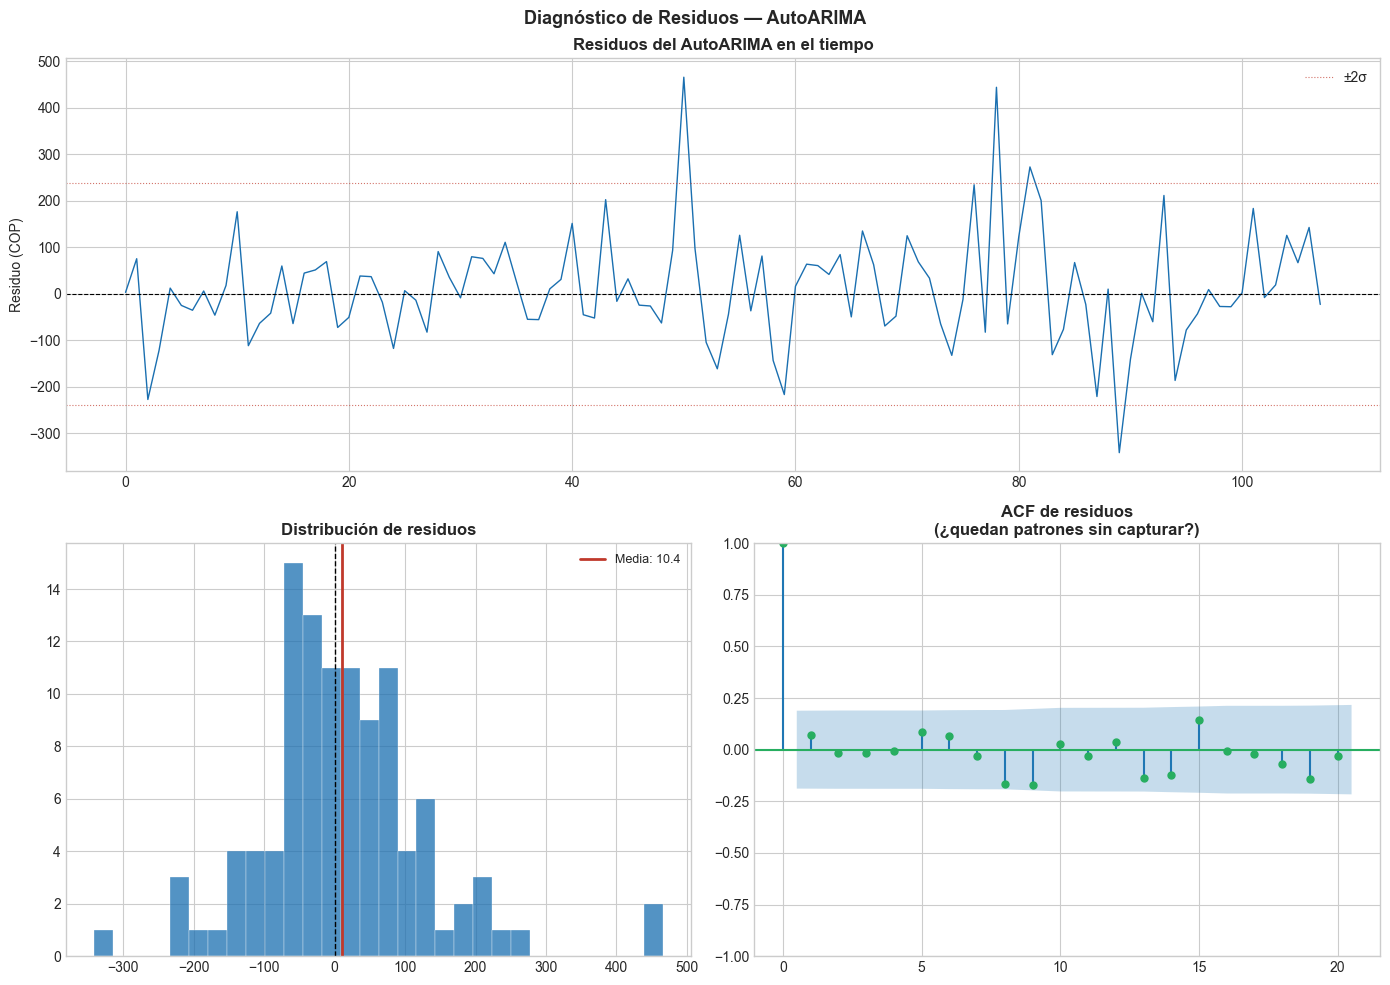


📊 TEST DE LJUNG-BOX (lag=10)
   p-valor: 0.5207
   ✅ Residuos parecen ruido blanco (p > 0.05)
   El modelo capturó toda la estructura de la serie
✅ Guardado como 11_diagnostico_residuos.png


In [19]:
# Calcular residuos del AutoARIMA en el período de entrenamiento
col_arima = [c for c in cols_base if 'arima' in c.lower()][0]

# Pronóstico in-sample (sobre el train)
fitted_vals = modelos.forecast_fitted_values()

if fitted_vals is not None and not fitted_vals.empty:
    fitted_vals = fitted_vals.reset_index()
    col_fitted = [c for c in fitted_vals.columns if 'arima' in c.lower()]
    if col_fitted:
        fitted_arima = fitted_vals[col_fitted[0]]
        y_train_vals = train['y'].values[-len(fitted_arima):]
        residuos = pd.Series(y_train_vals - fitted_arima.values)
    else:
        residuos = pd.Series(np.diff(train['y'].values))
else:
    # Residuos aproximados: primera diferencia de la serie (válido para ARIMA(0,1,0))
    residuos = pd.Series(np.diff(train['y'].values))
    print('ℹ️  Usando primera diferencia como aproximación de residuos')

residuos = residuos.dropna()

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Residuos en el tiempo
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuos.values, color='#1a6fb0', linewidth=1)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.axhline(residuos.std() * 2, color='#c0392b', linewidth=0.8,
            linestyle=':', alpha=0.7, label='±2σ')
ax1.axhline(-residuos.std() * 2, color='#c0392b', linewidth=0.8,
            linestyle=':', alpha=0.7)
ax1.set_title('Residuos del AutoARIMA en el tiempo', fontweight='bold')
ax1.set_ylabel('Residuo (COP)')
ax1.legend()

# Histograma de residuos
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuos, bins=30, color='#1a6fb0', alpha=0.75,
         edgecolor='white', linewidth=0.3)
ax2.axvline(residuos.mean(), color='#c0392b', linewidth=2,
            label=f'Media: {residuos.mean():.1f}')
ax2.axvline(0, color='black', linewidth=1, linestyle='--')
ax2.set_title('Distribución de residuos', fontweight='bold')
ax2.legend(fontsize=9)

# ACF de residuos
ax3 = fig.add_subplot(gs[1, 1])
plot_acf(residuos, lags=20, ax=ax3, color='#27ae60')
ax3.set_title('ACF de residuos\n(¿quedan patrones sin capturar?)', fontweight='bold')

fig.suptitle('Diagnóstico de Residuos — AutoARIMA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_diagnostico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

# Test de Ljung-Box
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
pvalor = lb_test['lb_pvalue'].values[0]
print(f'\n📊 TEST DE LJUNG-BOX (lag=10)')
print(f'   p-valor: {pvalor:.4f}')
if pvalor > 0.05:
    print('   ✅ Residuos parecen ruido blanco (p > 0.05)')
    print('   El modelo capturó toda la estructura de la serie')
else:
    print('   ⚠️  Residuos tienen autocorrelación (p ≤ 0.05)')
    print('   Hay estructura en la serie que el modelo no capturó')
print('✅ Guardado como 11_diagnostico_residuos.png')

### 🔍 Sección B — Después de ver los resultados

---

#### 👁️ Nivel 1: Lectura de resultados

1. ¿Qué modelo eligió AutoARIMA (p, d, q)? ¿Se confirmó tu hipótesis de ARIMA(0,1,0)?
2. Compara el MAE de AutoARIMA con el del Naive de la Fase 2 ($435.14). ¿Mejoró, empeoró o fue igual?
3. Mira los residuos en el tiempo. ¿Parecen aleatorios o tienen algún patrón visible?
4. ¿Cuál es el p-valor del test de Ljung-Box? ¿Qué concluyes con ese número?

---

#### 🧠 Nivel 2: Interpretación

5. Si AutoARIMA eligió exactamente ARIMA(0,1,0), ¿qué significa eso en términos de qué información del pasado es útil para predecir la TRM?
6. Si los residuos pasan el test de Ljung-Box (p > 0.05), ¿eso significa que el modelo es bueno o solo que no hay autocorrelación en los errores? ¿Son lo mismo?
7. Mira el histograma de residuos. ¿La distribución es simétrica? ¿Tiene colas gruesas (valores muy extremos más frecuentes de lo esperado)? ¿Qué implicaciones tiene eso?
8. Si el MAE de AutoARIMA es prácticamente igual al del Naive, ¿qué valor tuvo entonces correr AutoARIMA? ¿Fue un ejercicio inútil?

---

#### 💼 Nivel 3: Conclusión del proyecto

9. Con los resultados de las tres fases, ¿cuál es tu conclusión final sobre la predictibilidad de la TRM? Resume en 3-4 oraciones como si se lo explicaras a un gerente.
10. ¿Qué tipo de modelo podría superar al Naive para la TRM? ¿Qué información adicional necesitaría usar?
11. **Pregunta de portafolio:** Si alguien lee tu GitHub y te pregunta *'¿por qué usaste tres modelos si el Naive ganó desde el principio?'*, ¿qué le respondes?
12. Mira todo el proyecto desde la Fase 1 hasta acá. ¿Cuál fue la conclusión más sorprendente o contraintuitiva que encontraste?

---

## 9. Exportar resultados finales

In [20]:
tabla_completa.to_csv('fase3_resultados_finales.csv')
comparacion.to_csv('fase3_comparacion_arima.csv', index=False)

print('✅ Archivos exportados:')
print('   📄 fase3_resultados_finales.csv')
print('   📄 fase3_comparacion_arima.csv')
print()
print('🎯 FASE 3 COMPLETA')
print('=' * 50)
print('Próximo paso: Fase 4 — Conclusiones y presentación del portafolio')

✅ Archivos exportados:
   📄 fase3_resultados_finales.csv
   📄 fase3_comparacion_arima.csv

🎯 FASE 3 COMPLETA
Próximo paso: Fase 4 — Conclusiones y presentación del portafolio


---

## ✅ Resumen de la Fase 3

### ¿Qué hicimos?
1. Analizamos ACF y PACF para entender la estructura de autocorrelación de la TRM
2. Corrimos AutoARIMA y verificamos qué modelo eligió automáticamente
3. Comparamos AutoARIMA contra todos los modelos de la Fase 2
4. Diagnosticamos los residuos con el test de Ljung-Box

### Concepto central de esta fase
AutoARIMA no es magia — es una búsqueda sistemática del mejor modelo ARIMA dado los datos. Que converja al mismo resultado que el Naive **no es un fracaso**: es evidencia estadística de que la serie tiene una estructura específica (random walk) que los modelos más simples ya capturan completamente.

---
*Proyecto basado en: Forecasting: Principles and Practice, the Pythonic Way — Hyndman et al. (2025)*